In [2]:
import pandas as pd

transactions_df = pd.read_csv('../data/transactions.tar.gz', compression='gzip')
target_df = pd.read_csv('../data/gender_train.csv')

# Filter
transactions_df = transactions_df[transactions_df['customer_id'].isin(target_df['customer_id'])]

# Merge
df = transactions_df.merge(target_df, on='customer_id')

In [3]:
df.head()

,customer_id,tr_datetime,mcc_code,tr_type,amount,term_id,gender
0,39026145,0 10:23:26,4814,1030,-2245.92,NaN,1
1,39026145,1 10:19:29,6011,7010,56147.89,NaN,1
2,39026145,1 10:20:56,4829,2330,-56147.89,NaN,1
3,39026145,1 10:39:54,5499,1010,-1392.47,NaN,1
4,39026145,2 15:33:42,5499,1010,-920.83,NaN,1


df

# Creating a descriptions

In [ ]:
# import pandas as pd

# df = pd.read_csv('./data/tr_types_new.csv', sep=';')
# df.rename(columns={'tr_type': 'code', "tr_description": "description"}, inplace=True)
# df.reset_index(drop=True, inplace=True)

# df.to_csv('./data/tr_types.csv', index=False, sep=',')

In [ ]:
# df = pd.read_csv('./data/tr_mcc_codes.csv', sep=';')
# df.rename(columns={'mcc_code': 'code', "mcc_description": "description"}, inplace=True)
# df.reset_index(drop=True, inplace=True)

# df.to_csv('./data/mcc_codes.csv', index=False, sep=',')

In [5]:
tr_type2desc = pd.read_csv('../data/tr_types.csv').set_index("code")['description'].to_dict()
mcc_code2desc = pd.read_csv('../data/mcc_codes.csv').set_index("code")['description'].to_dict()

df["tr_type_desc"] = df.tr_type.map(tr_type2desc).fillna('')
df["mcc_code_desc"] = df.mcc_code.map(mcc_code2desc).fillna('')

# Creating embeddings for descriptions

In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')  # 384-dim output

/Users/savkin/miniconda3/envs/sber_interp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/savkin/miniconda3/envs/sber_interp/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/savkin/miniconda3/envs/sber_interp/lib/python3.10/runpy.py", line 86, in _run_cod

In [9]:
unique_tr = df[['tr_type', 'tr_type_desc']].drop_duplicates().dropna()
tr_texts = unique_tr['tr_type_desc'].tolist()
tr_embeddings = model.encode(tr_texts, show_progress_bar=True)

tr_type_to_emb = dict(zip(unique_tr['tr_type'], tr_embeddings))


unique_mcc = df[['mcc_code', 'mcc_code_desc']].drop_duplicates().dropna()
mcc_texts = unique_mcc['mcc_code_desc'].tolist()
mcc_embeddings = model.encode(mcc_texts, show_progress_bar=True)

mcc_code_to_emb = dict(zip(unique_mcc['mcc_code'], mcc_embeddings))

Batches: 100%|██████████| 3/3 [00:00<00:00,  9.62it/s]


RuntimeError: Numpy is not available

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
tr_type_emb_reduced = pca.fit_transform(list(tr_type_to_emb.values()))
tr_type_to_emb_reduced = dict(zip(tr_type_to_emb.keys(), tr_type_emb_reduced))

pca = PCA(n_components=10)
mcc_code_emb_reduced = pca.fit_transform(list(mcc_code_to_emb.values()))
mcc_code_to_emb_reduced = dict(zip(mcc_code_to_emb.keys(), mcc_code_emb_reduced))

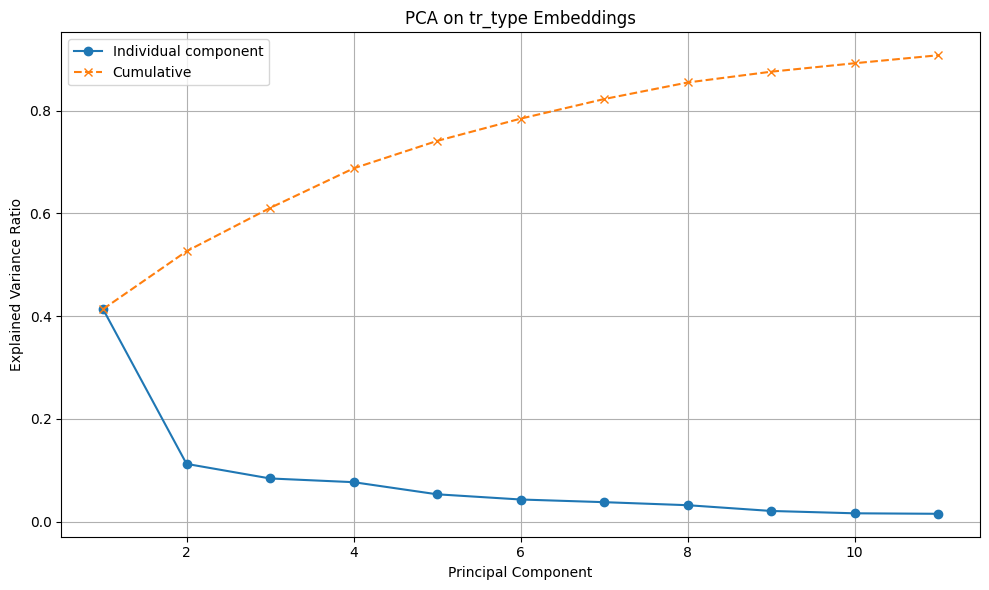

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Assuming tr_type_to_emb is a dictionary of vectors
emb_matrix = np.stack(list(tr_type_to_emb.values()))

# Run PCA

n_components = 11
pca = PCA(n_components=0.90)
tr_type_emb_reduced = pca.fit_transform(emb_matrix)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, n_components+1), pca.explained_variance_ratio_, marker='o', label='Individual component')
plt.plot(np.arange(1, n_components+1), np.cumsum(pca.explained_variance_ratio_), marker='x', linestyle='--', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA on tr_type Embeddings')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
import json

with open("./data/mcc2emb.json", "w") as file:
    mcc2emb = {int(k): v.tolist() for k, v in mcc_code_to_emb_reduced.items()}
    json.dump(mcc2emb, file, indent=4)

with open("./data/tr_type2emb.json", "w") as file:
    tr_type2emb = {int(k): v.tolist() for k, v in tr_type_to_emb_reduced.items()}
    json.dump(tr_type2emb, file, indent=4)

In [6]:
# Change customer_id's
import pandas as pd

def remap_columns(df, columns):
    df = df.copy()
    for col in columns:
        unique_vals = df[col].unique()
        val_map = {val: idx for idx, val in enumerate(unique_vals)}
        df[col] = df[col].map(val_map)
    return df

df = remap_columns(df, ['customer_id', 'mcc_code', 'tr_type'])

df.head()

,customer_id,tr_datetime,mcc_code,tr_type,amount,term_id,gender,tr_type_desc,mcc_code_desc
0,0,0 10:23:26,0,0,-2245.92,NaN,1,Оплата услуги. Банкоматы СБ РФ,"Звонки с использованием телефонов, считывающих..."
1,0,1 10:19:29,1,1,56147.89,NaN,1,Взнос наличных через АТМ (в своем тер.банке),Финансовые институты — снятие наличности автом...
2,0,1 10:20:56,2,2,-56147.89,NaN,1,Списание с карты по операции “перевода с карты...,Денежные переводы
3,0,1 10:39:54,3,3,-1392.47,NaN,1,Покупка. POS ТУ СБ РФ,"Различные продовольственные магазины — рынки, ..."
4,0,2 15:33:42,3,3,-920.83,NaN,1,Покупка. POS ТУ СБ РФ,"Различные продовольственные магазины — рынки, ..."


Fix datetime

In [ ]:
# Split into day offset and time
df[['day_offset', 'clock_time']] = df['tr_datetime'].str.split(' ', expand=True)

# Convert day_offset to int
df['day_offset'] = pd.to_numeric(df['day_offset'], errors='coerce')

# Fix invalid seconds (e.g., 10:54:60 → 10:54:59)
def fix_bad_time(t):
    try:
        h, m, s = map(int, t.split(":"))
        s = min(s, 59)
        return f"{h:02}:{m:02}:{s:02}"
    except:
        return np.nan

df['clock_time'] = df['clock_time'].apply(fix_bad_time)

# Convert to datetime (assuming day 0 = arbitrary start, say 2000-01-01)
df['tr_datetime'] = pd.to_datetime("2000-01-01") + pd.to_timedelta(df['day_offset'], unit='D') + pd.to_timedelta(df['clock_time'])

# Drop temp columns
df.drop(columns=['day_offset', 'clock_time'], inplace=True)

In [10]:
df.to_csv('../data/all.csv', index=False)